# The Solow Growth Model

## Project Description
This project provides a comprehensive exploration of the Solow growth model and some of its extensions. First, we look at the **standard Solow model** and explore the dynamics of the model. Then, we extend the model to a **Solow model with semi-endogenous technological growth** by allowing the productivity/technology parameter to change over time. Finally, we extend the standard Solow model to a **Solow model with human capital**.\
All three models are solved analytically and numerically, followed by an analysis of the dynamics of the models.

**Table of contents**<a id='toc0_'></a>    
- [1. The Standard Solow Model](#toc1_)    
  - [1.1. Analytical Solution](#toc1_1_)    
  - [1.2. Numerical Solution](#toc1_2_)    
  - [1.3. Analysis - Simulation and Comparative Analysis](#toc1_3_)  
      - [1.3.1. Simulation](#toc1_3_1_)  
      - [1.3.2. Different Initial Levels of Capital](#toc1_3_2_)  
      - [1.3.3. Different Savings Rates](#toc1_3_3_)  
      - [1.3.4. A Shock to Technology](#toc1_3_4_)  
- [2. Extensions of the Model](#toc2_)
  - [2.1. The Solow Model with Endogenous Technological Progress](#toc2_1_)  
      - [2.1.1. Analytical Solution](#toc2_1_1_)  
      - [2.1.2. Numerical Solution](#toc2_1_2_)  
      - [2.1.3. Simulation of the Solow model with technological progress](#toc2_1_3_)  
      - [2.1.4. Different Initial Levels of Capital](#toc2_1_4_)  
      - [2.1.5 Different Savings Rates](#toc2_1_5_)  
      - [2.1.6. A Shock to Technology](#toc2_1_6_)    
  - [2.2. The Solow Model with Human Capital](#toc2_1_)
      - [2.2.1. Analytical Solution](#toc2_2_1_)  
      - [2.2.2. Numerical Solution and Simulation](#toc2_2_2_)     
      - [2.2.3. Higher Savings Rates](#toc2_2_3_)      
- [3. Conclusion](#toc3_)   

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
from scipy import optimize
import sympy as sm
from types import SimpleNamespace
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# plotting
import matplotlib.pyplot as plt
plt.rcParams.update({"axes.grid":True,"grid.color":"black","grid.alpha":"0.25","grid.linestyle":"--"})
plt.rcParams.update({'font.size': 14})

In [2]:
import SolowModel as SolowModel
from SolowModel import Solow_model
from SolowModel import SolowModelWithTechProgress

from SolowModel import SolowModelwithHumanCapital

model = Solow_model()


## 1. <a id='toc1_'></a>   [The Standard Solow model](#toc0_)


Consider the **standard Solow-model** where:

1. $K_t$ is capital
2. $L_t$ is labor (growing with a constant rate of $n$)
3. $A$ is technology (constant over time)
4. $Y_t = F(K_t,A_tL_t)$ is GDP

We set population growth and technology growth equal to zero to keep things simple.

For every period t, output is given by:
$$
Y_{t} = F(K_{t},L_{t})
$$

The **production function** has **constant returns to scale** such that

$$
F(\lambda K, \lambda L) = \lambda F(K,L)
$$

The production function is a **Cobb-Douglas** production function
$$
F(K_{t},L_{t})=A K_{t}^{\alpha}L_{t}^{1-\alpha}, 0<=\alpha <=1
$$


We assume **closed economy** which implies 
$$
I_{t} = S_{t} 
$$

**Saving** is a constant fraction of GDP

$$ 
S_t = sY_t,\,s\in(0,1)
$$

The capital depreciates with the rate $\delta$ in each period. Such that **capital accumulates** according to

$$
K_{t+1}=S_{t}+(1-\delta)K_{t}=sF(K_{t},L_{t})+(1-\delta)K_{t}, \delta \in (0,1)
$$

As we don't have population growth, $L_t$ is some constant L.

Capital per capita is given by $k_{t}=K_{t}/L$. We can write the capital accumulation equation as

$$
k_{t+1}= s \frac{F(K_{t}L)}{L} + (1-\delta)k_{t} = sAk_{t}^\alpha + (1-\delta)k_{t}
$$


## 1.1 <a id='toc1_1_'></a>   [Analytical Solution](#toc0_)

At first, we will solve the model analytically using sympy.

In [3]:
SolowModel.Solow_analytical()

The steady state equation for k is:


(A*s/delta)**(-1/(alpha - 1))


## 1.2 <a id='toc1_2_'></a>   [Numerical Solution](#toc0_)

We will now use the analytical steady state of k to find a numerical solution given some parameter definitions. We use the following baseline parameters in our numerical analysis:
$$
\alpha = 0.3
$$

$$
\delta = 0.1
$$

$$
s=0.2
$$

$$
A=2
$$

In [4]:
model.run()

The steady state for k is 7.24578931411126


## 1.3 <a id='toc1_3_'></a>   [Analysis - Simulation and Comparative Analysis](#toc0_)
We want to look further into the dynamics of our model by comparing it with the theoretical dynamics


### 1.3.1. <a id='toc1_3_1_'></a>   [Simulation](#toc0_)

Now, we will make a visualisation of the transition of capital to the steady state. The following graph shows the transition of capital per worker over time. It illustrates how the economy moves from an initial capital stock to its steady-state equilibrium, highlighting the effects of capital accumulation and depreciation.

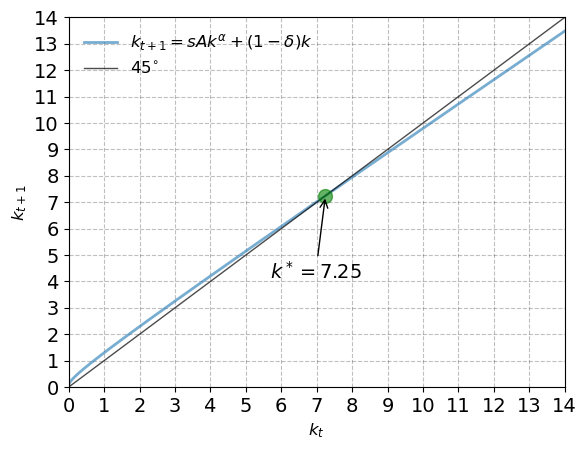

In [5]:
model = Solow_model()
model.plot45()

By plotting the capital per worker against time, we see that the economy in our model move towards their long-run equilibrium, their steady state. The 45° line is where $k_{t+1}=k_{t}$. This is where the steady state is obtained. The point where the capital accumulation graph crosses the 45° line, is the steady state value of capital. 

When $k_{t+1}$ is below $k_{t}$, the transition equation graph lies above the 45-degree line. This indicates that $k_{t+1}$ is greater than $k_{t}$, meaning the capital stock per worker is increasing over time as the economy moves towards the steady state.

When $k_{t+1}$ is above $k_{t}$, the transition equation graph lies below the 45-degree line. This indicates that $k_{t+1}$ is less than $k_{t}$, meaning the capital stock per worker is decreasing over time as the economy moves towards the steady state.

The crossing of the 45-degree line at $k^*$ illustrates the principle of convergence in the Solow model. Regardless of whether the initial capital stock is above or below $k^*$, we see that the economy will converge to the steady-state level of capital over time. This convergence is driven by the diminishing returns to capital and the balance between savings/investment and depreciation.

The steady state value of capital in our model is 7.25.


### 1.3.2. <a id='toc1_3_2_'></a>   [Different Initial Levels of Capital](#toc0_)

We will now show the capital paths for three distinct initial capital levels. The figure illustrates the convergence property of the Solow model by depicting how the economy will converge towards the same steady state level of capital per worker regardless of the initial level of capital per worker.

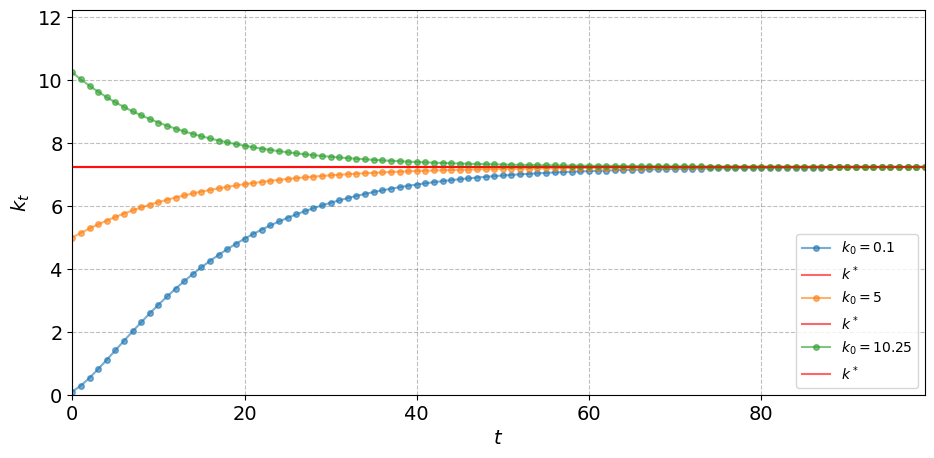

In [6]:
k_ini_values = np.array([0.1, 5, 10.25])
model.simulate(k_ini_values)

We see that for all initial levels of capital, the capital accumulation will converge towards the steady state level $k^*$. I.e., the initial level of capital is not important on the long run.

We see that if the economy has a low level of initial capital per worker, the transition path slopes upwards, indicating that capital per worker is increasing over time. This happens because the marginal product of capital is high when capital is scarce, leading to higher returns on investment and faster accumulation of capital. This is also why the slope is steeper for the lowest initial level of capital per worker (compared to the second lowest level).

If, on the other hand, the economy has a high level of initial capital per worker, the transition path slopes downwards, indicating that capital per worker is decreasing over time. This occurs because the marginal product of capital is low when capital is abundant, leading to lower returns on investment and possibly higher depreciation rates, which reduce capital over time.

Both mechanisms result in the convergence towards the steady state level of capital per worker.


### 1.3.3. <a id='toc1_3_3_'></a>   [Different Savings Rates](#toc0_)
In the Solow model, the households save a fraction of their current incomes. These savings increase the capital of the economy.
We will now illustrate how different savings rates affect the steady state of capital. The figure demonstrates the relationship between the savings rate and the economic outcomes on the long run, emphasizing the role of savings in determining the capital stock, and thereby, also the standard of living.

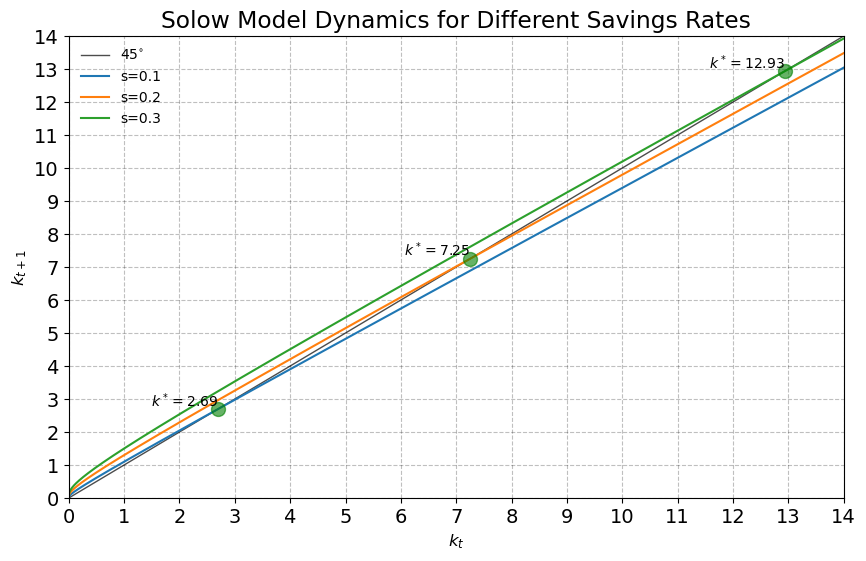

In [7]:
newmodel_combined = Solow_model()
newmodel_combined.plot_combined([0.1, 0.2, 0.3])

We see that the steady state of capital increases with the savings fraction. This reflects that a higher savings rate implies higher investment in capital accumulation. I.e., our model corresponds with the theoretical relationship between capital and savings.


### 1.3.4. <a id='toc1_3_4_'></a>   [A Shock to Technology](#toc0_)

Now, we will illustrate the impact of a positive technological shock in period 0 on capital accumulation and steady state levels.

The steady state for k is 7.24578931411126
The steady state for k is 9.966176578193432


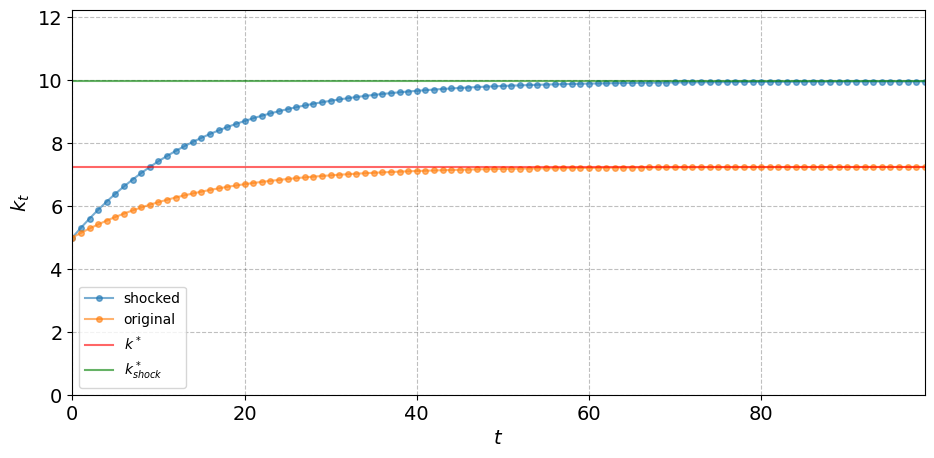

In [8]:
# Create an instance of Solow_model
newmodel = Solow_model()

# Set the shock to A
newmodel.A = 2.5
for i in range(0, 100):
    newmodel.newA[i] = 2.5

# Plot the combined graph before and after the technology shock
newmodel.plot_technology_shock_combined()

The figure demonstrates how a sudden improvement in technology shifts the economy's trajectory, leading to a higher steady-state level of capital per worker and thereby also a higher steady state level output per worker. This corresponds to the theoretical Solow model.

The figure highlights the significant role of technological progress in economic growth and underscores the importance of policies that promote innovation in technology.



## 2. <a id='toc2_'></a>   [Extensions of the Model](#toc0_)


## 2.1. <a id='toc2_1_'></a>   [Solow Model with Endogenous Technological Progress](#toc0_)

It seems like the technological level in the economy has great importance to the capital accumulation on the long run. That was one of the conclusions from looking at the standard Solow Model where the technology is exogenously given. \
Now, we consider an extension to the standard Solow model by endogenizing the technological.\
It gives us the Solow model with semi-endogenous technological progress:

$$
Y_{t}=K_{t}^\alpha (A_{t}L_{t})^{(1-\alpha)}
$$

$$
A_{t}=K_{t}^{\phi}
$$

$$
K_{t+1}=sY_{t}+(1-\delta)K_{t}
$$

$$
L_{t+1}=(1+n)L_{t}
$$

We look at the model in *per effective worker* terms. I.e., we consider variables as:

$$
\tilde k_{t}=\frac{K_{t}}{A_{t}L_{t}}
$$

and likewise for other variables.

This implies that the production function is given by:

$$
\tilde y_{t}=\tilde k_{t}^\alpha
$$

And the capital accumulation equation is given by:

$$
\tilde k_{t+1} = \frac {1}{(1+n)} \tilde k_{t} [s \tilde k_{t}^{\alpha - 1} + (1-\delta)]^{1-\phi}
$$

*The semi-endogenous technological progress means that some aspects of the technological progress are endogenous (influenced by economic variables and decisions within the model itself). As the model now contains population growth, some of the economic growth might originate from this population growth.*

### 2.1.1. <a id='toc2_1_1_'></a>   [Analytical Solution](#toc0_)

In [9]:
SolowModel.Solow_TechProg_analytical()

Steady-state value of k:


((delta - 1 + (n + 1)**(-1/(phi - 1)))/s)**(1/(alpha - 1))

Substituting the steady-state value of k into the SS equation for y yields the following steady-state value of y:


(((delta - 1 + (n + 1)**(-1/(phi - 1)))/s)**(1/(alpha - 1)))**alpha

These are the same steady state equations that we know from the book "Introducing Advanced Macroeconomics: Growth and Business Cycles".


### 2.1.2. <a id='toc2_1_2_'></a>   [Numerical Solution](#toc0_)

In the numerical solution, we use the following baseline parameter values:
$$
\alpha = 0.3
$$
$$
\delta = 0.1
$$
$$
s = 0.2
$$
$$
n = 0.01
$$
$$
\phi = 0.5

$$

In [10]:
TechModel=SolowModelWithTechProgress()

steady_state_k=TechModel.find_steady_state()
print(f"Steady state values of (k,y) are: {steady_state_k}")

Steady state values of (k,y) are: (2.0720965289851527, 1.244293965655597)


### 2.1.3. <a id='toc2_1_3_'></a>   [Simulation of the Solow model with technological progress](#toc0_)

Now, we will plot the transition equation of capital in the Solow model with endogenous technological progress to understand the dynamics of the capital accumulation:

/Users/agnetenielsen/projects-2024-agnete-og-andrea-12/modelproject/SolowModel.py:336: RuntimeWarning: divide by zero encountered in power
  return (1 / (1 + self.n)) * k * (self.s * k**(self.alpha - 1) + (1 - self.delta))**(1 - self.phi)
/Users/agnetenielsen/projects-2024-agnete-og-andrea-12/modelproject/SolowModel.py:336: RuntimeWarning: invalid value encountered in multiply
  return (1 / (1 + self.n)) * k * (self.s * k**(self.alpha - 1) + (1 - self.delta))**(1 - self.phi)


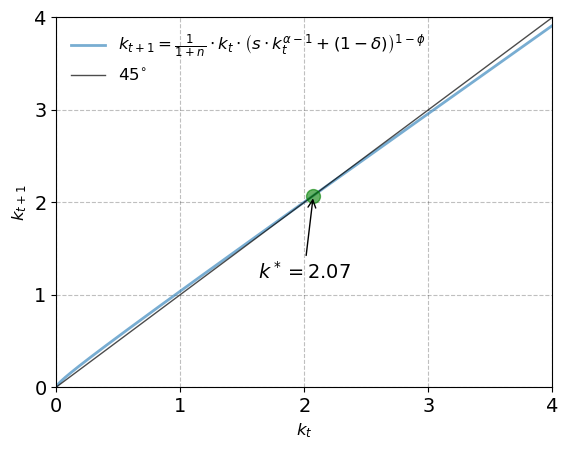

In [11]:
TechModel=SolowModelWithTechProgress()
TechModel.plot45()

Again, we see that regardless of whether the initial capital stock is above or below $k^*$, the economy will converge to the steady-state level of capital over time. The steady state of capital per worker is 2.07.


### 2.1.4. <a id='toc2_1_4_'></a>   [Different initial values of capital](#toc0_)

We will now look into how the transition paths of capital look for different initial values of capital accumulation.

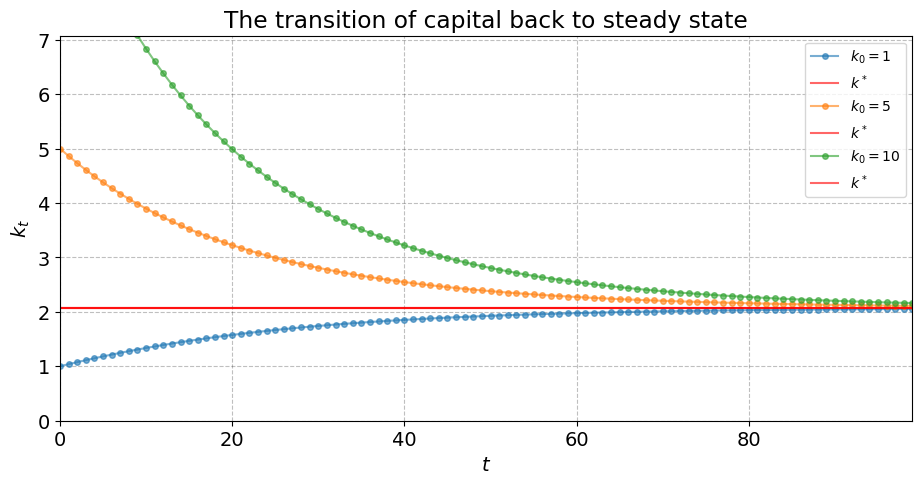

In [12]:
# Simulate and plot the transition of capital for different initial values
TechModel=SolowModelWithTechProgress()
initial_capitals = [1, 5, 10]
TechModel.simulate(initial_capitals)

As expected, all the transition paths (no matter the initial value of capital) converge towards $k^*$ on the long run.

As in the standard Solow model, at low initial levels of capital per worker the marginal product of capital is high (because capital is scarce), leading to higher returns on investment and faster accumulation of capital.

Opposite for high initial levels of capital per worker: Low marginal product of capital, which leads to lower returns on investment, which will lead to a reduction in capital.

### 2.1.5. <a id='toc2_1_5_'></a>   [Different Savings Rates](#toc0_)


Now, we will investigate how the savings rate affects the steady state value of capital.

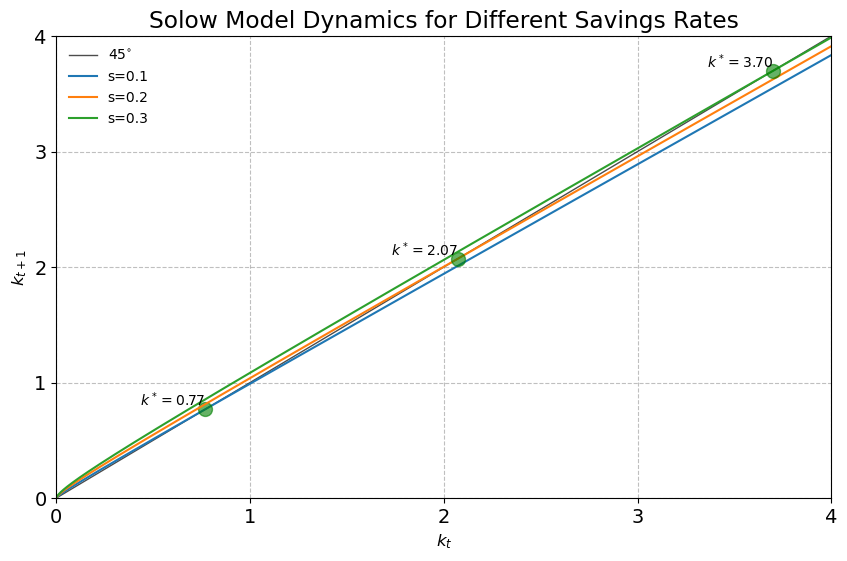

In [13]:
# Plot combined effects for different savings rates
savings_rates = [0.1, 0.2, 0.3]
TechModel.plot_combined(savings_rates)

The figure shows that the higher the savings rate is, the higher level of steady state capital accumulation. I.e., there is a positive relationship between the savings rate and the capital accumulation. This is because the savings are invested in capital.

### 2.1.6. <a id='toc2_1_6_'></a>   [A Shock to Technology](#toc0_)

Even though, we have endogenized some of the technological progress, it is still interesting to make a shock to the exogenous part of the technology.

We make a shock to the parameter $\alpha$. In the Solow model with semi-endogenous technological progress, $\alpha$ represents the output elasticity of capital. This influences how sensitive the output is to changes in capital. A technological shock can be represented by $\alpha$ to reflect an improvement in technology that affects the productivity of capital. A higher $\alpha$ increases the marginal product of capital, leading to a higher investment in capital. This captures the essence of a technological shock, which typically results in more efficient use of capital and higher output levels.

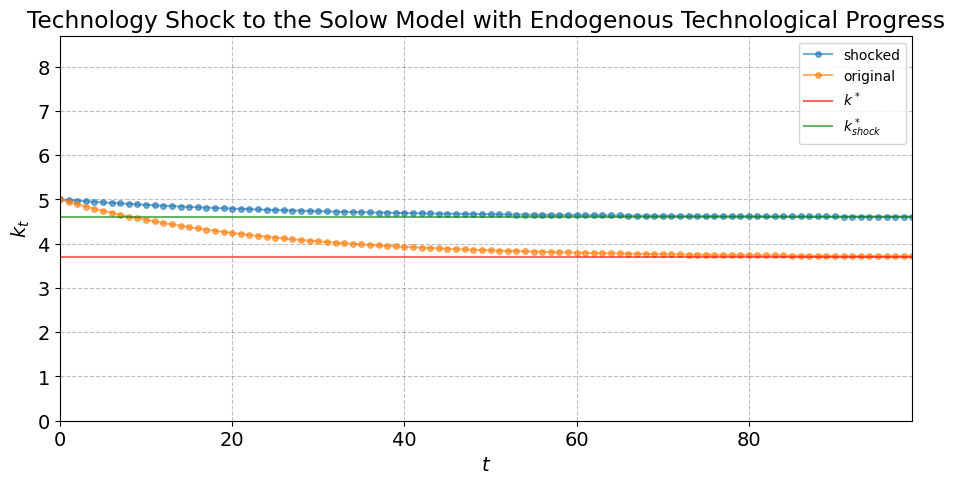

In [14]:
# Plot combined effects of technology shocks
TechModel.plot_technology_shock_combined()

The figure shows the different transition paths for the baseline technological level (where $\alpha=0.3$) and for a higher technological level ($\alpha=0.4$). We see that the steady state level of capital per worker is higher, when the technological level is higher. 


## 2.2. <a id='toc2_2_'></a>   [The Solow Model with Human Capital](#toc0_)


Now, we create an extension of the classic Solow model that includes human capital in the production function. 

The model equations:

$$
Y_t = K_t ^\alpha H_t ^\phi (A_t*L_t)^{(1-\alpha-\phi)}
$$

The technology adjusted variables:
$$
\tilde{y} _t = \tilde{k} _t ^\alpha  \tilde{h}_t ^\phi
$$

The technology adjusted capital accumulation equations:

$$
\tilde{k}_{t+1}=\frac{1}{(1+n)(1+g)} (s_K \tilde{y}_t +(1-\delta)\tilde{k}_t)
$$

$$
\tilde {h}_{t+1}=\frac{1}{(1+n)(1+g)} (s_H \tilde{y}_t +(1-\delta)\tilde{h}_t)
$$

Inserting the equation for $\tilde{y}_t$ yields:
$$
\tilde{k}_{t+1}=\frac{1}{(1+n)(1+g)} (s_K\tilde{k} _t ^\alpha  \tilde{h}_t ^\phi +(1-\delta)\tilde{k}_t)
$$

$$
\tilde {h}_{t+1}=\frac{1}{(1+n)(1+g)} (s_H \tilde{k} _t ^\alpha  \tilde{h}_t ^\phi +(1-\delta)\tilde{h}_t)
$$


### 2.2.1. <a id='toc2_2_1_'></a>   [Analytical Solution](#toc0_)

In [15]:
SolowModel.SolowHuman_analytical_capital()

The steady state equation for k is:


((delta + g*n + g + n)/(h**phi*s_k))**(1/(alpha - 1))

In [16]:
SolowModel.SolowHuman_analytical_humancapital()

The steady state equation for h is:


((delta + g*n + g + n)/(k**alpha*s_h))**(1/(phi - 1))

Now, we want to combine the SS values. I.e. use the SS value of human capital in the SS equation for physical capital. We do this by substituting the SS value of human capital into the SS capital equation and isolate k. After that, we can insert the expression for $k^*$ in the steady state equation for h. Thereby, we will have a SS value for both human capital and physical capital.

In [17]:
SolowModel.SolowHuman_analytical_combined()


The combined steady state equation for k is:


((delta + g*n + g + n)/(s_k*(((delta + g*n + g + n)/(k**alpha*s_h))**(1/(phi - 1)))**phi))**(1/(alpha - 1))

The combined steady state equation for h is:


((delta + g*n + g + n)/(s_h*(((delta + g*n + g + n)/(h**phi*s_k))**(1/(alpha - 1)))**alpha))**(1/(phi - 1))

The analytical solution to k:


[]

The analytical solution to h:


[]

This indicates that there is no analytical solution or that the equation system is too complex for Python to solve.\
We didn't manage to get the analytical steady state values for H and K as equations that don't depend on the two variables. 


### 2.2.2. <a id='toc2_2_2_'></a>   [Numerical solution and simulation of the Solow model with human capital](#toc0_)
We simulate the model by first finding the numerical steady state values and then plot the phase diagram that shows the transition paths of human capital and physical capital.

Since we didn't succeed in finding the analytical solution in our code, we use the analytical solutions that are given in the book "Introducing Advanced Macroeconomics: Growth and Business Cycles". 

In this book, the steady state values for physical capital and human capital are given by:
$$
\tilde{k}^*=[\frac{(s_K^{1-\phi}*s_H^{\phi})}{(n+g+\delta+ng))}]^{1/(1-\alpha-\phi)}
$$
$$
\tilde{h}^*=[\frac{(s_K^{\alpha}*s_H^{1-\alpha})}{(n+g+\delta+ng))}]^{1/(1-\alpha-\phi)}
$$

We use these expressions in our further analysis.

For the numerical solution, we use the baseline parameters:
$$
\alpha = 0.3
$$
$$
\delta = 0.1
$$
$$
s_k = 0.2
$$
$$
s_h = 0.1
$$
$$
n = 0.01
$$
$$
\phi = 0.5

$$
$$
A=2
$$
$$
g=0.02
$$


Steady-state value for capital (k*): 1.5118895595561044
Steady-state value for human capital (h*): 0.7559447797780535


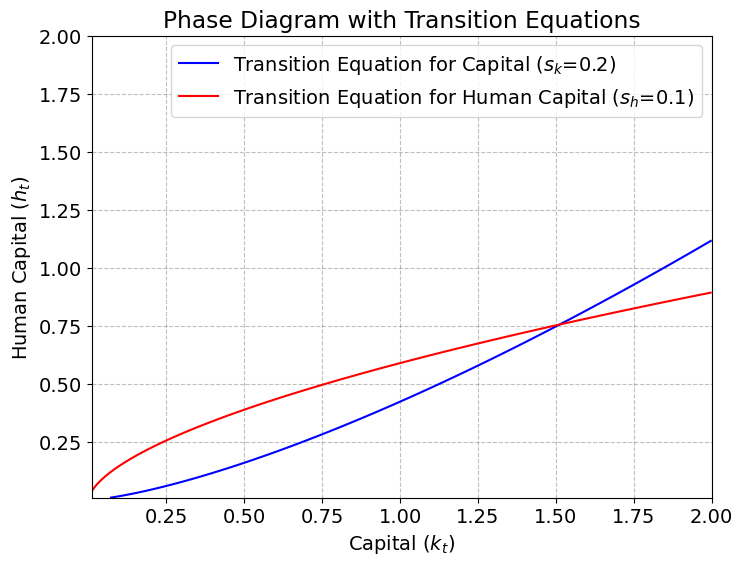

In [18]:
model = SolowModelwithHumanCapital()

model.run()
model.plot_phase_diagram_transition_equations()


The figure is a visual representation of the Solow model with human capital. It illustrates the dynamics of the physical capital and the human capital relative to each other. The steady state is where the two curves intersect. The phase diagram shows that with the given parameter values, the steady state of (physical capital, human capital) is at (1.51, 0.76). This suggests that in steady state, the economy would tend to have a higher value of physical capital than human capital.

### 2.2.3. <a id='toc2_2_3_'></a>   [Higher Savings Rates](#toc0_)

Now, we investigate how an increase in each of the savings rates affect the steady state level of physical and human capital. We increase the savings in physical capital to 0.3 and the savings in human capital to 0.2.

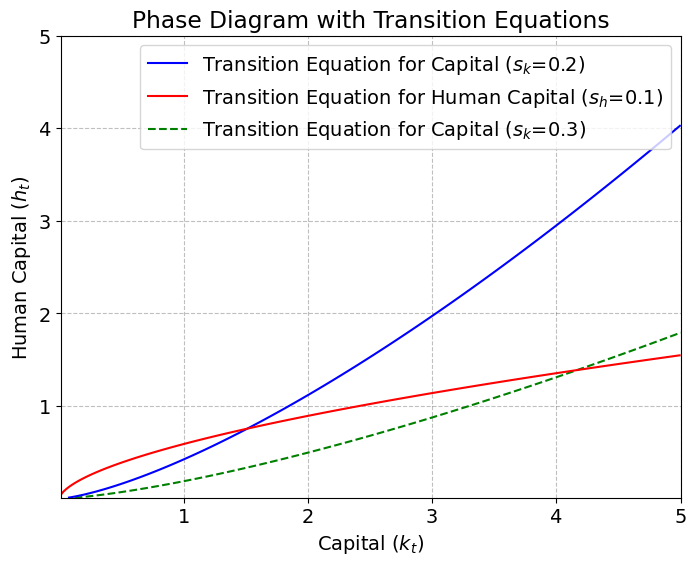

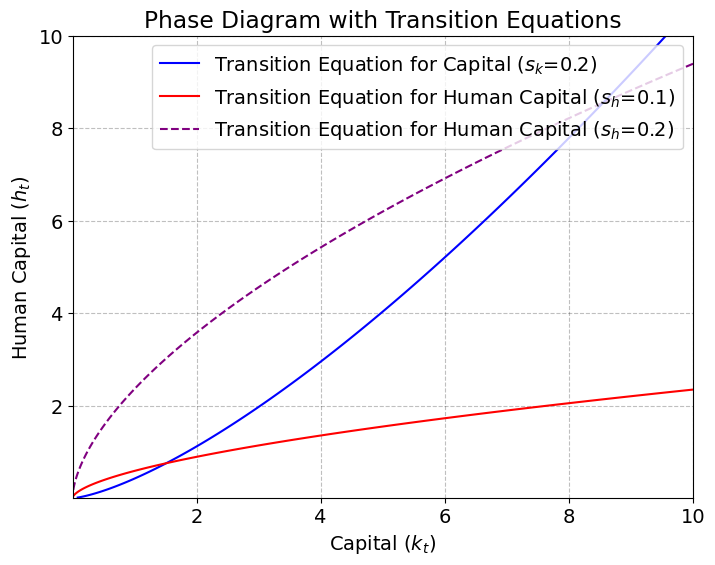

In [19]:
model = SolowModelwithHumanCapital()
model.plot_phase_diagram_with_higher_savings(sk_high=0.3)  # Plot extended phase diagram with higher savings rate for capital
model.plot_phase_diagram_with_higher_human_capital_savings(sh_high=0.2)  # Plot extended phase diagram with higher savings rate for human capital

The first figure shows an increase in the savings rate for physical capital.
We see that when increasing the savings in physical capital, the steady state values for both physical and human capital increases. 

The second figure shows the effect of an increase in the savings rate for human capital. 
An increase in the savings rate in human capital causes the steady state values for both physical and human capital to increase.

This is the case, as both of the transition equations are dependent on both of the savings rates. There are interactions between the physical capital and the human capital. Both of the savings rates affect the output per worker, and the savings are a fraction of the output per worker, so a higher output per worker implies a higher level of saving in both human and physical capital in the next period.


## 3. <a id='toc3_'></a>   [Conclusion](#toc0_)

This project has investigated the dynamics of three different versions of the Solow model. For each model, we have found the analytical solution, the numerical solution, and made an analysis of the dynamics of the model.

The **standard Solow model** performs well under simulation and exhibits convergence towards a steady state. Under further analysis we show that our model coorporates with the wellknown  dynamics of the theoretical model. This is shown by varying the initial value of capital per worker. Regardless of the initial value of capital per worker, the economy converges back to the steady state on the long run. The model exhibits a positive relationship between the savings rate and the steady state level of capital. Positive technological shocks results in an increase in the steady state of capital per worker. All of this corresponds with the theoretical Solow model.

In the analysis of the standard Solow model, we found that the technology has great importance on the steady state level of capital per worker. Therefore, we extend the standard Solow model to a **Solow model with semi-endogenous technological progress**. Now, technology can change over time and some of it is endogenized (as opposed to the standard Solow model where technology is exogenously given). Again, we find the analytical solution to the model, followed by the numerical solution and an analysis of the dynamics of the model. We make the same figures for this model as for the standard Solow model: Different initial levels of capital per worker, different savings rates, and a shock to (exogenous part of) the technology. We conclude that the model with semi-endogenous technological growth also corresponds with the theoretical Solow model.

Finally, we extend the standard Solow model to a **Solow model with human capital**. Now, there are two savings rates; one for savings in human capital and one for savings in physical capital. We plot two figures that shows the impact of a change in each of the savings rates. A change in just one of the savings rates affects both types of capital per worker (positively correlated). This is because the savings rates affect the output per worker, and output per worker affects the capital levels.


In summary, while the basic Solow model emphasizes capital accumulation, the extended model with human capital incorporates education and health effects, and the model with endogenous technological progress integrates dynamic technological change as a central driver of economic growth. Each model provides insights into different aspects of economic development and can help policymakers by informing them on strategies to promote sustainable growth and improve living standards in economies.